# Castaldi et al organoid dataset: processed adata for plots of the paper

[Reference paper](https://doi.org/10.1038/s41592-024-02555-5)

## 1. Environment Set Up

### 1.1 Library upload

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import igraph as ig
import matplotlib.pyplot as plt 
from scipy.sparse import csr_matrix, isspmatrix
from datetime import datetime
import sys
sys.path.append('../')
import functions as fn

print(np.__version__)
print(pd.__version__)
print(sc.__version__)

1.23.5
2.0.0
1.9.3


In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100)

### 1.2 Starting computations: timestamp

In [3]:
print(datetime.now())

2026-04-27 13:29:58.962382


## 2. Read input files

### 2.1 adata loading

In [4]:
adata = sc.read('../../../../Castaldi_multiplexingCBO/adataPaga.h5ad')

In [5]:
adata

AnnData object with n_obs × n_vars = 14913 × 3499
    obs: 'dataset', 'cellID', 'cellID_newName', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'stage', 'type', 'id_stage', 'cellID_newName_type', 'S_score', 'G2M_score', 'phase', 'leidenAnnotated', 'leiden_1.2', 'endpoint_GlutamatergicNeurons_late', 'endpoint_GlutamatergicNeurons_early', 'endpoint_MigratingNeurons', 'endpoint_OuterRadialGliaAstrocytes', 'endpoint_Interneurons', 'endpoint_Interneurons_GAD2', 'endpoint_CajalR_like', 'Exc_Lineage', 'endpoint_GlutamatergicNeurons_both'
    var: 'highly_variable', 'mean', 'std'
    uns: 'Exc_Lineage_colors', 'cellID_colors', 'cellID_newName_colors', 'cellID_newName_type_colors', 'cluster_colors', 'dataset_colors', 'diffmap_evals', 'draw_graph', 'leiden', 'leidenAnnotated_colors', 'leiden_1.2_colors', 'leiden_1.2_sizes', 'leide

In [6]:
print('Loaded Normalizes AnnData object: number of cells', adata.n_obs)
print('Loaded Normalizes AnnData object: number of genes', adata.n_vars)

# To see the columns of the metadata (information available for each cell)  
print('Available metadata for each cell: ', adata.obs.columns)

Loaded Normalizes AnnData object: number of cells 14913
Loaded Normalizes AnnData object: number of genes 3499
Available metadata for each cell:  Index(['dataset', 'cellID', 'cellID_newName', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'stage', 'type', 'id_stage', 'cellID_newName_type', 'S_score',
       'G2M_score', 'phase', 'leidenAnnotated', 'leiden_1.2',
       'endpoint_GlutamatergicNeurons_late',
       'endpoint_GlutamatergicNeurons_early', 'endpoint_MigratingNeurons',
       'endpoint_OuterRadialGliaAstrocytes', 'endpoint_Interneurons',
       'endpoint_Interneurons_GAD2', 'endpoint_CajalR_like', 'Exc_Lineage',
       'endpoint_GlutamatergicNeurons_both'],
      dtype='object')


In [7]:
np.unique(adata.obs.values[:,14])

array(['downstream', 'upstream'], dtype=object)

## 3. Visualizations

### 3.1 Counts from adata

In [8]:
adata.obsm

AxisArrays with keys: X_diffmap, X_draw_graph_fa, X_pca, X_umap

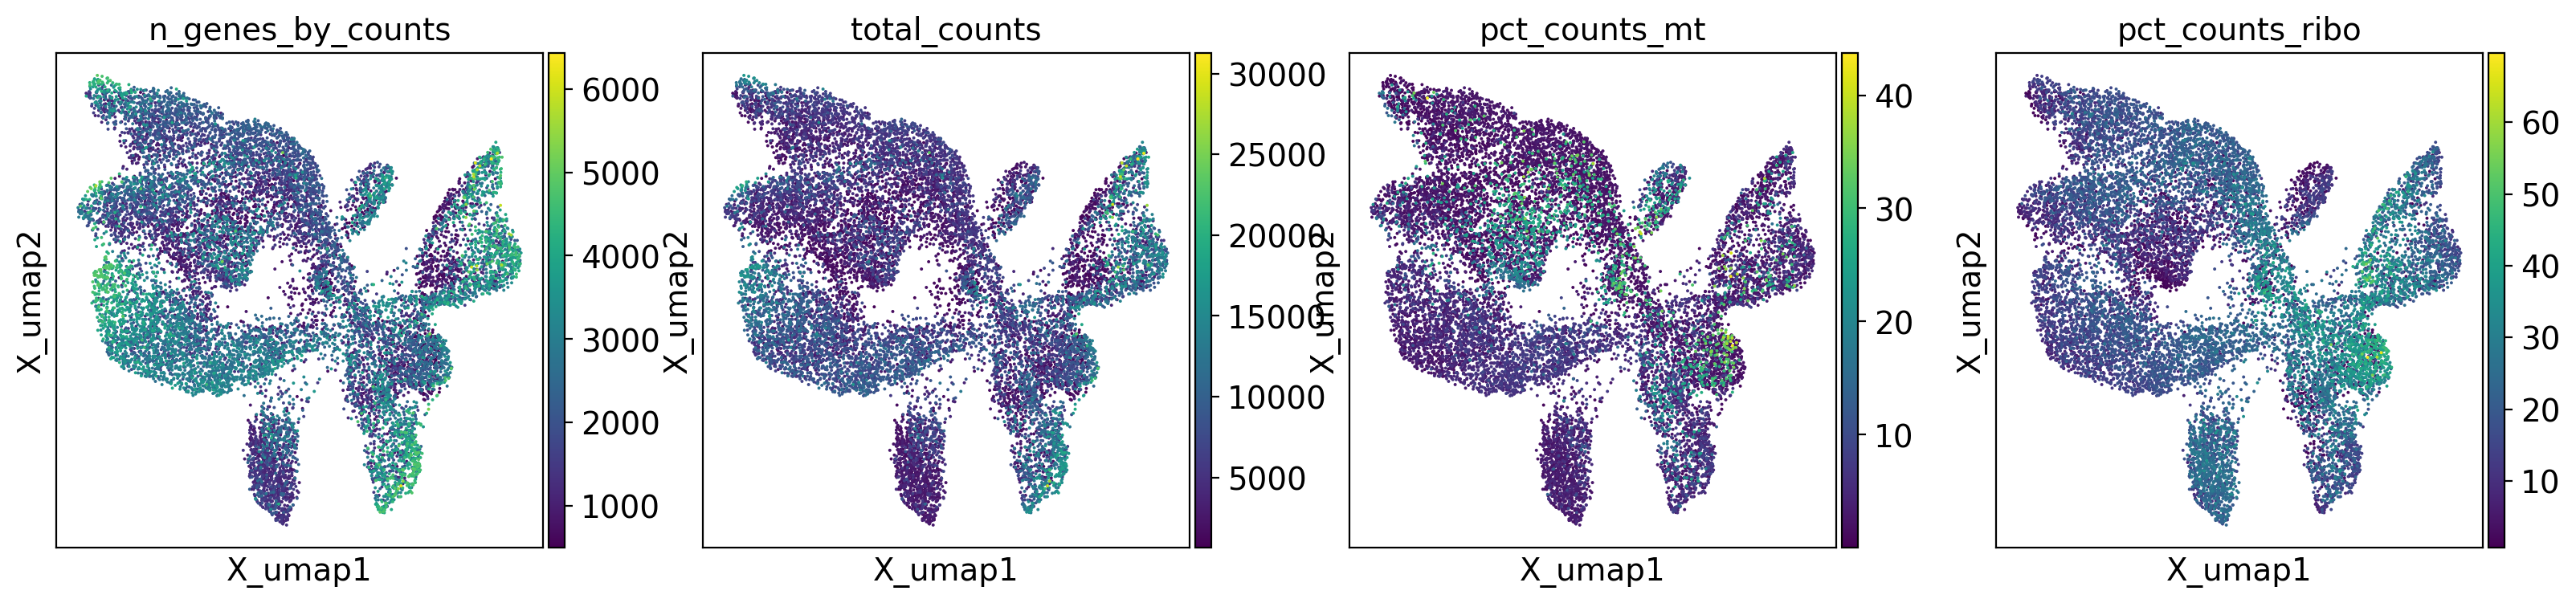

In [9]:
sc.pl.embedding(adata, basis="X_umap", color=['n_genes_by_counts',"total_counts", 'pct_counts_mt', 'pct_counts_ribo'])

### 3.2 Clusters annotation

/usr/local/lib/python3.8/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


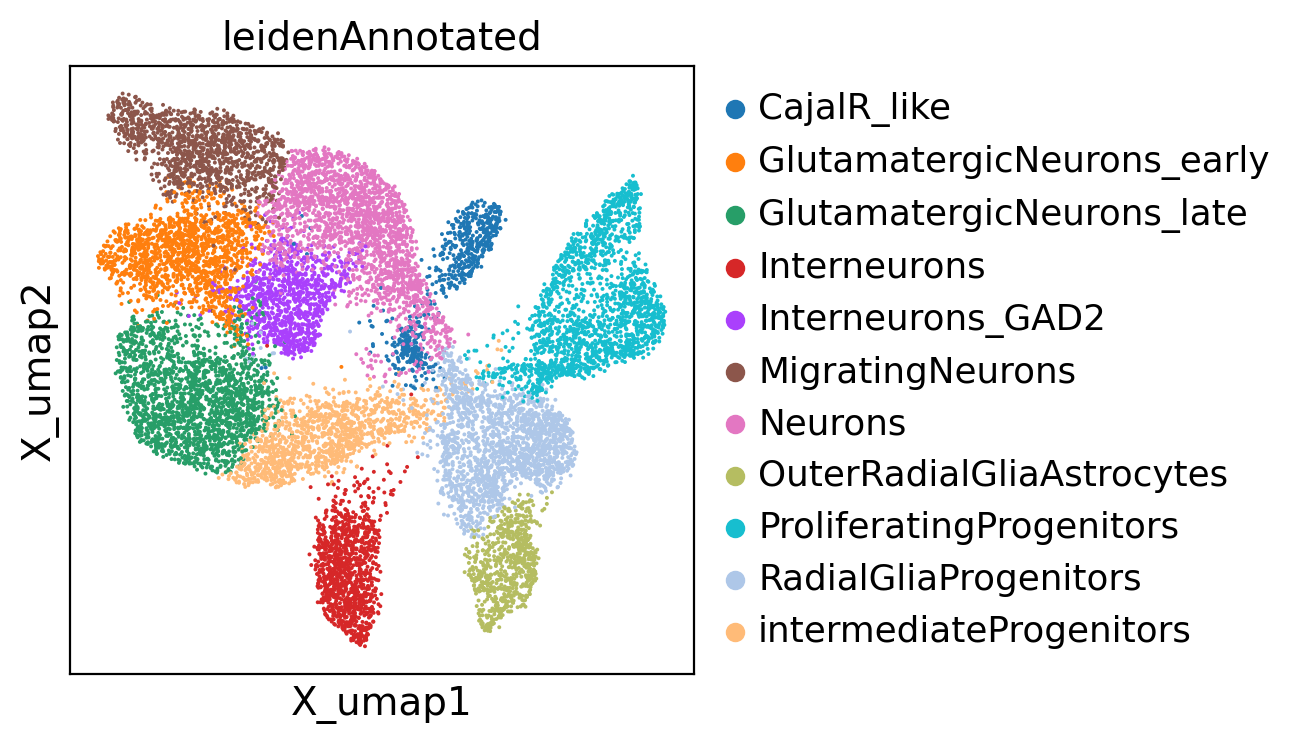

In [10]:
sc.pl.embedding(adata,  basis="X_umap", color=['leidenAnnotated'], ncols=1)

/usr/local/lib/python3.8/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


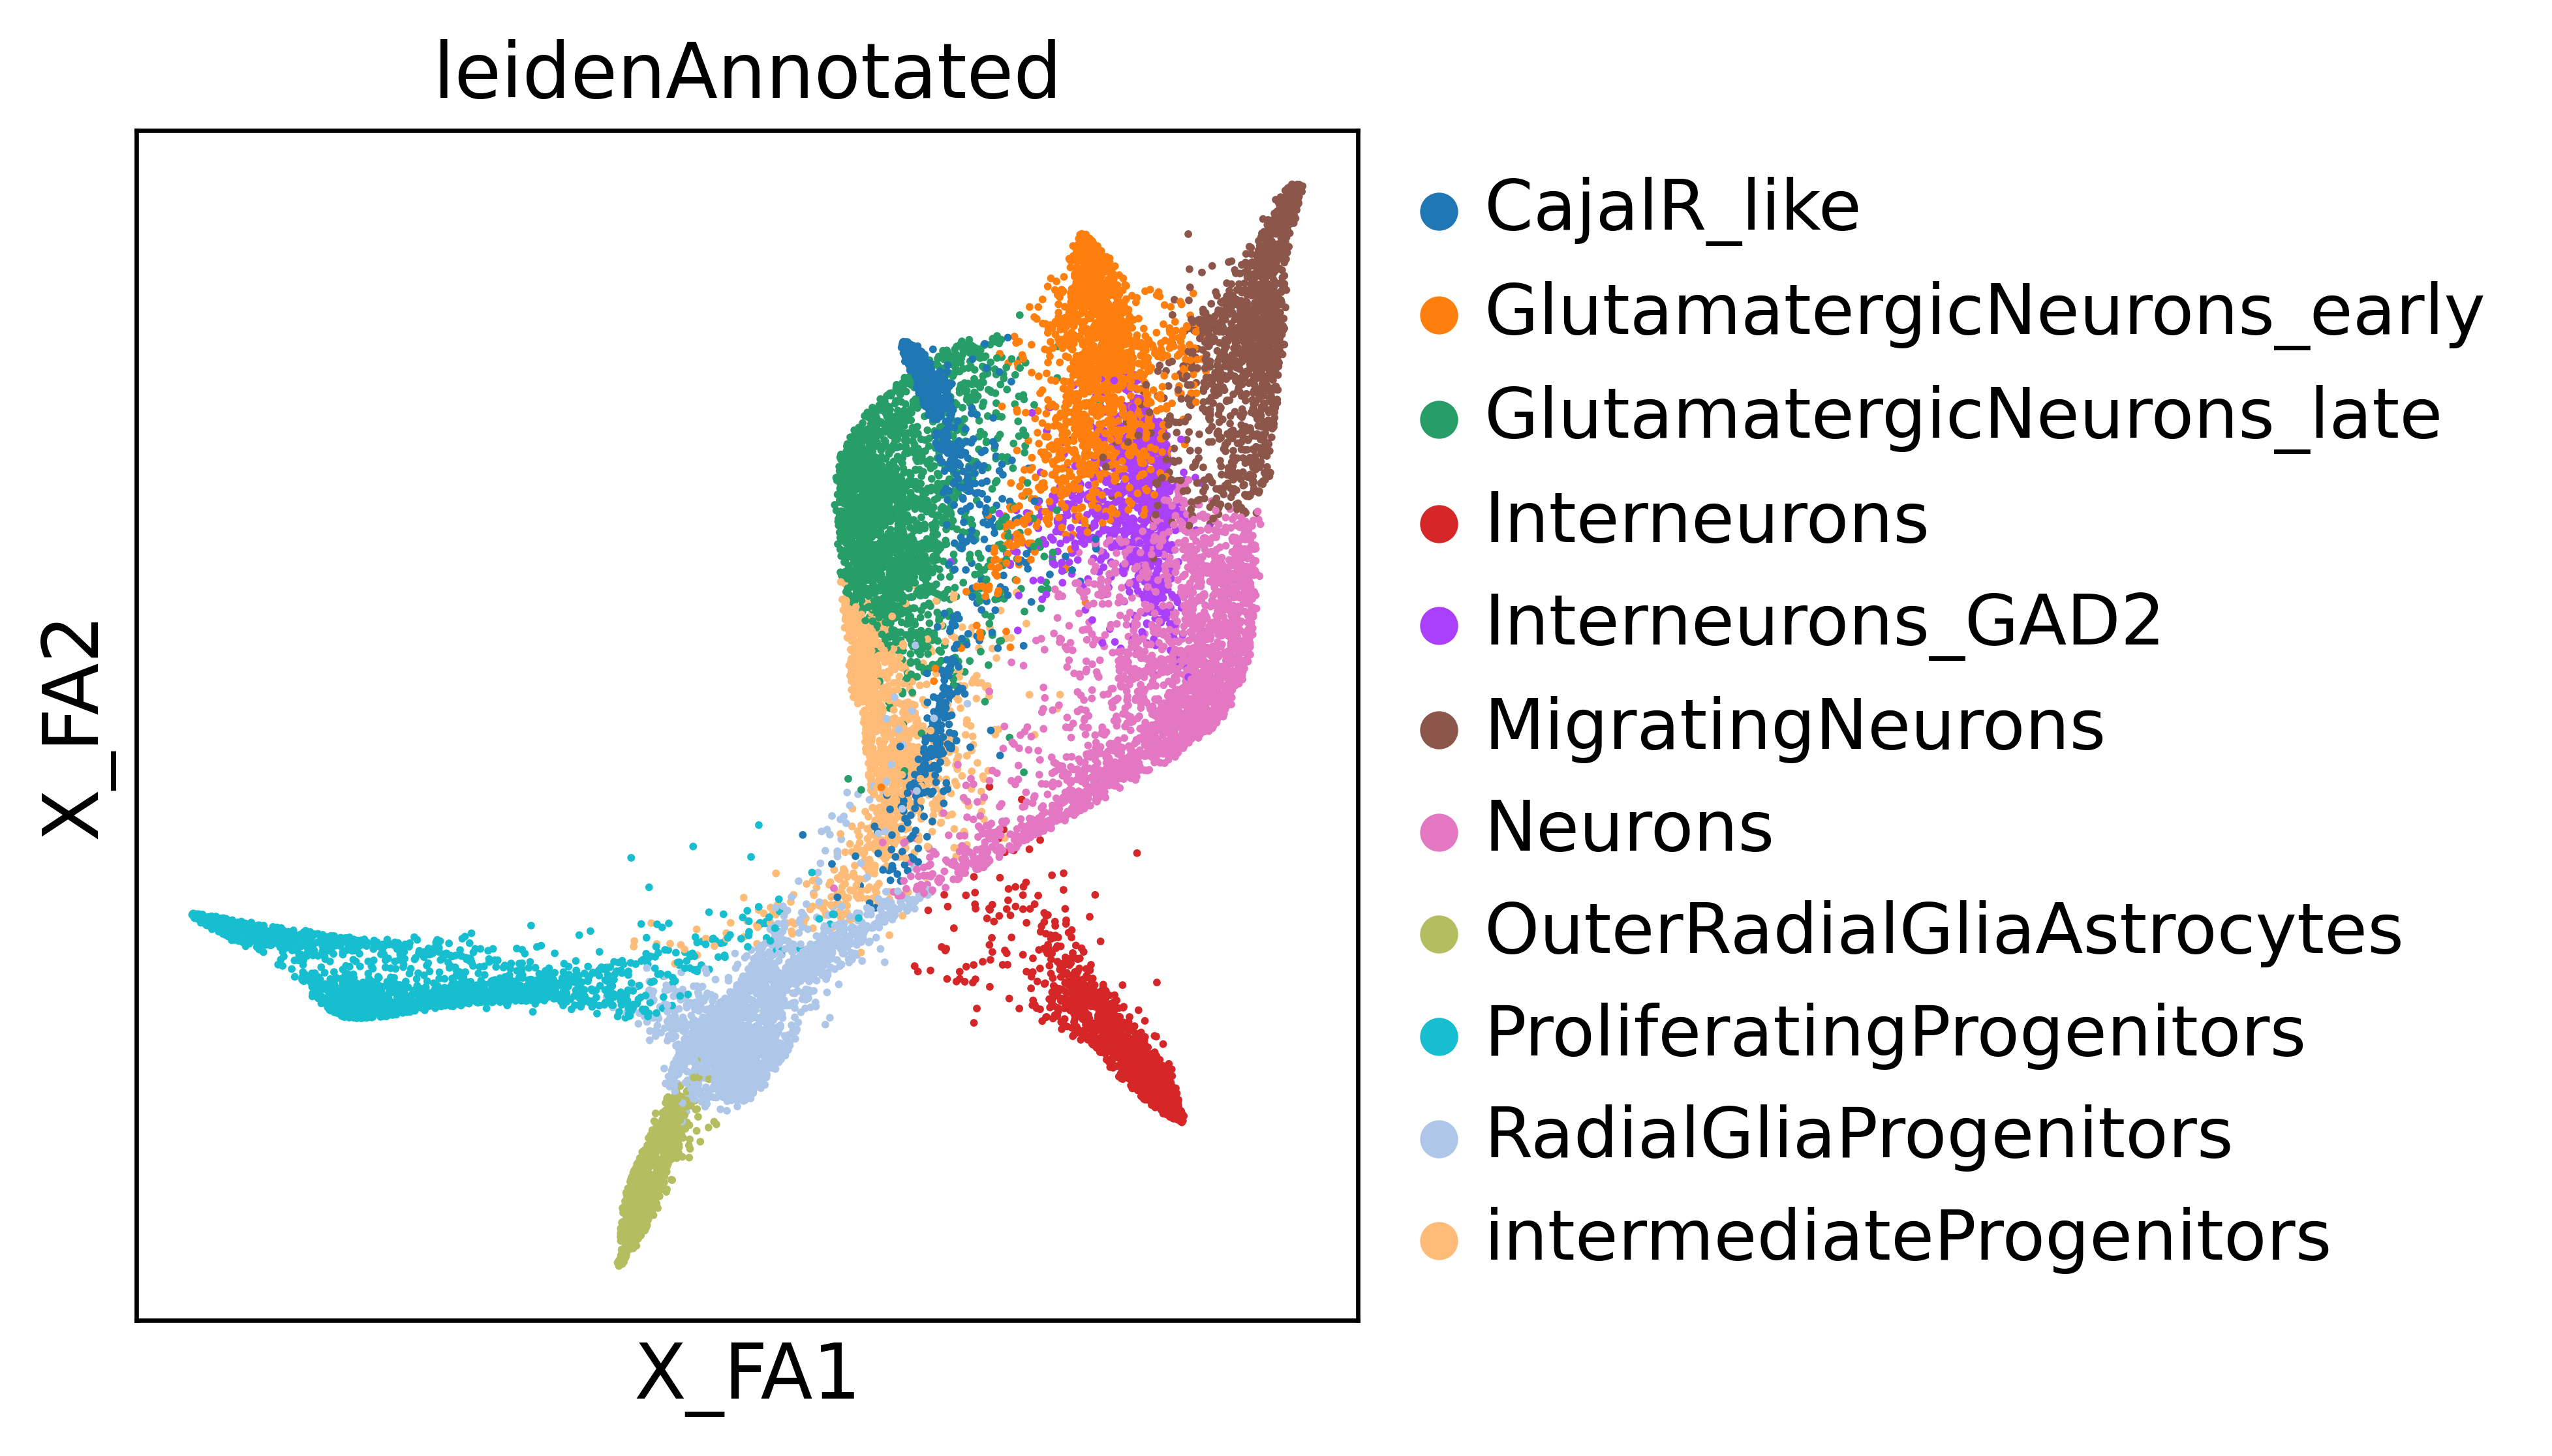

In [11]:
sc.settings.figdir = "../../../../FigPaper/"

sc.set_figure_params(dpi=300, dpi_save=600)

sc.pl.embedding(
    adata,
    basis="X_draw_graph_fa",
    color=['leidenAnnotated'],
    ncols=1,
    save="CastaldiAll_highres.png"
)

In [12]:
print(datetime.now())

2026-04-27 13:30:04.726093
